# 입력데이터와 결과데이터

> info 함수로 컬럼 정보 확인

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report)


df = pd.read_csv('train%20(1).csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


> 컬럼명 한글로 변경

In [ ]:
df.rename(columns={'datetime': '대여시간',
                   'season': '계절',
                   'holiday': '공휴일 여부',
                   'workingday': '근무일 여부',
                   'weather': '날씨상황',
                   'temp': '실제온도',
                   'atemp': '체감온도',
                   'humidity': '습도',
                   'windspeed': '풍속',
                   'casual': '등록되지 않은 사용자 대여수',
                   'registered': '등록된 사용자 대여수',
                   'count': '총 대여수'}, inplace=True)
df

,대여시간,계절,공휴일 여부,근무일 여부,날씨상황,실제온도,체감온도,습도,풍속,등록되지 않은 사용자 대여수,등록된 사용자 대여수,총 대여수
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


> 통계표

In [ ]:
df.describe()

,계절,공휴일 여부,근무일 여부,날씨상황,실제온도,체감온도,습도,풍속,총 대여수,대여수_많음,연,월,요일,시
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,191.574132,0.073213,2011.501929,6.521495,3.013963,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,181.144454,0.260498,0.500019,3.444373,2.004585,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,1.000000,0.000000,2011.000000,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,42.000000,0.000000,2011.000000,4.000000,1.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,145.000000,0.000000,2012.000000,7.000000,3.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,284.000000,0.000000,2012.000000,10.000000,5.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,977.000000,1.000000,2012.000000,12.000000,6.000000,23.000000


> 통계표를 통해 숫자형 데이터 기본 통계 정보 확인

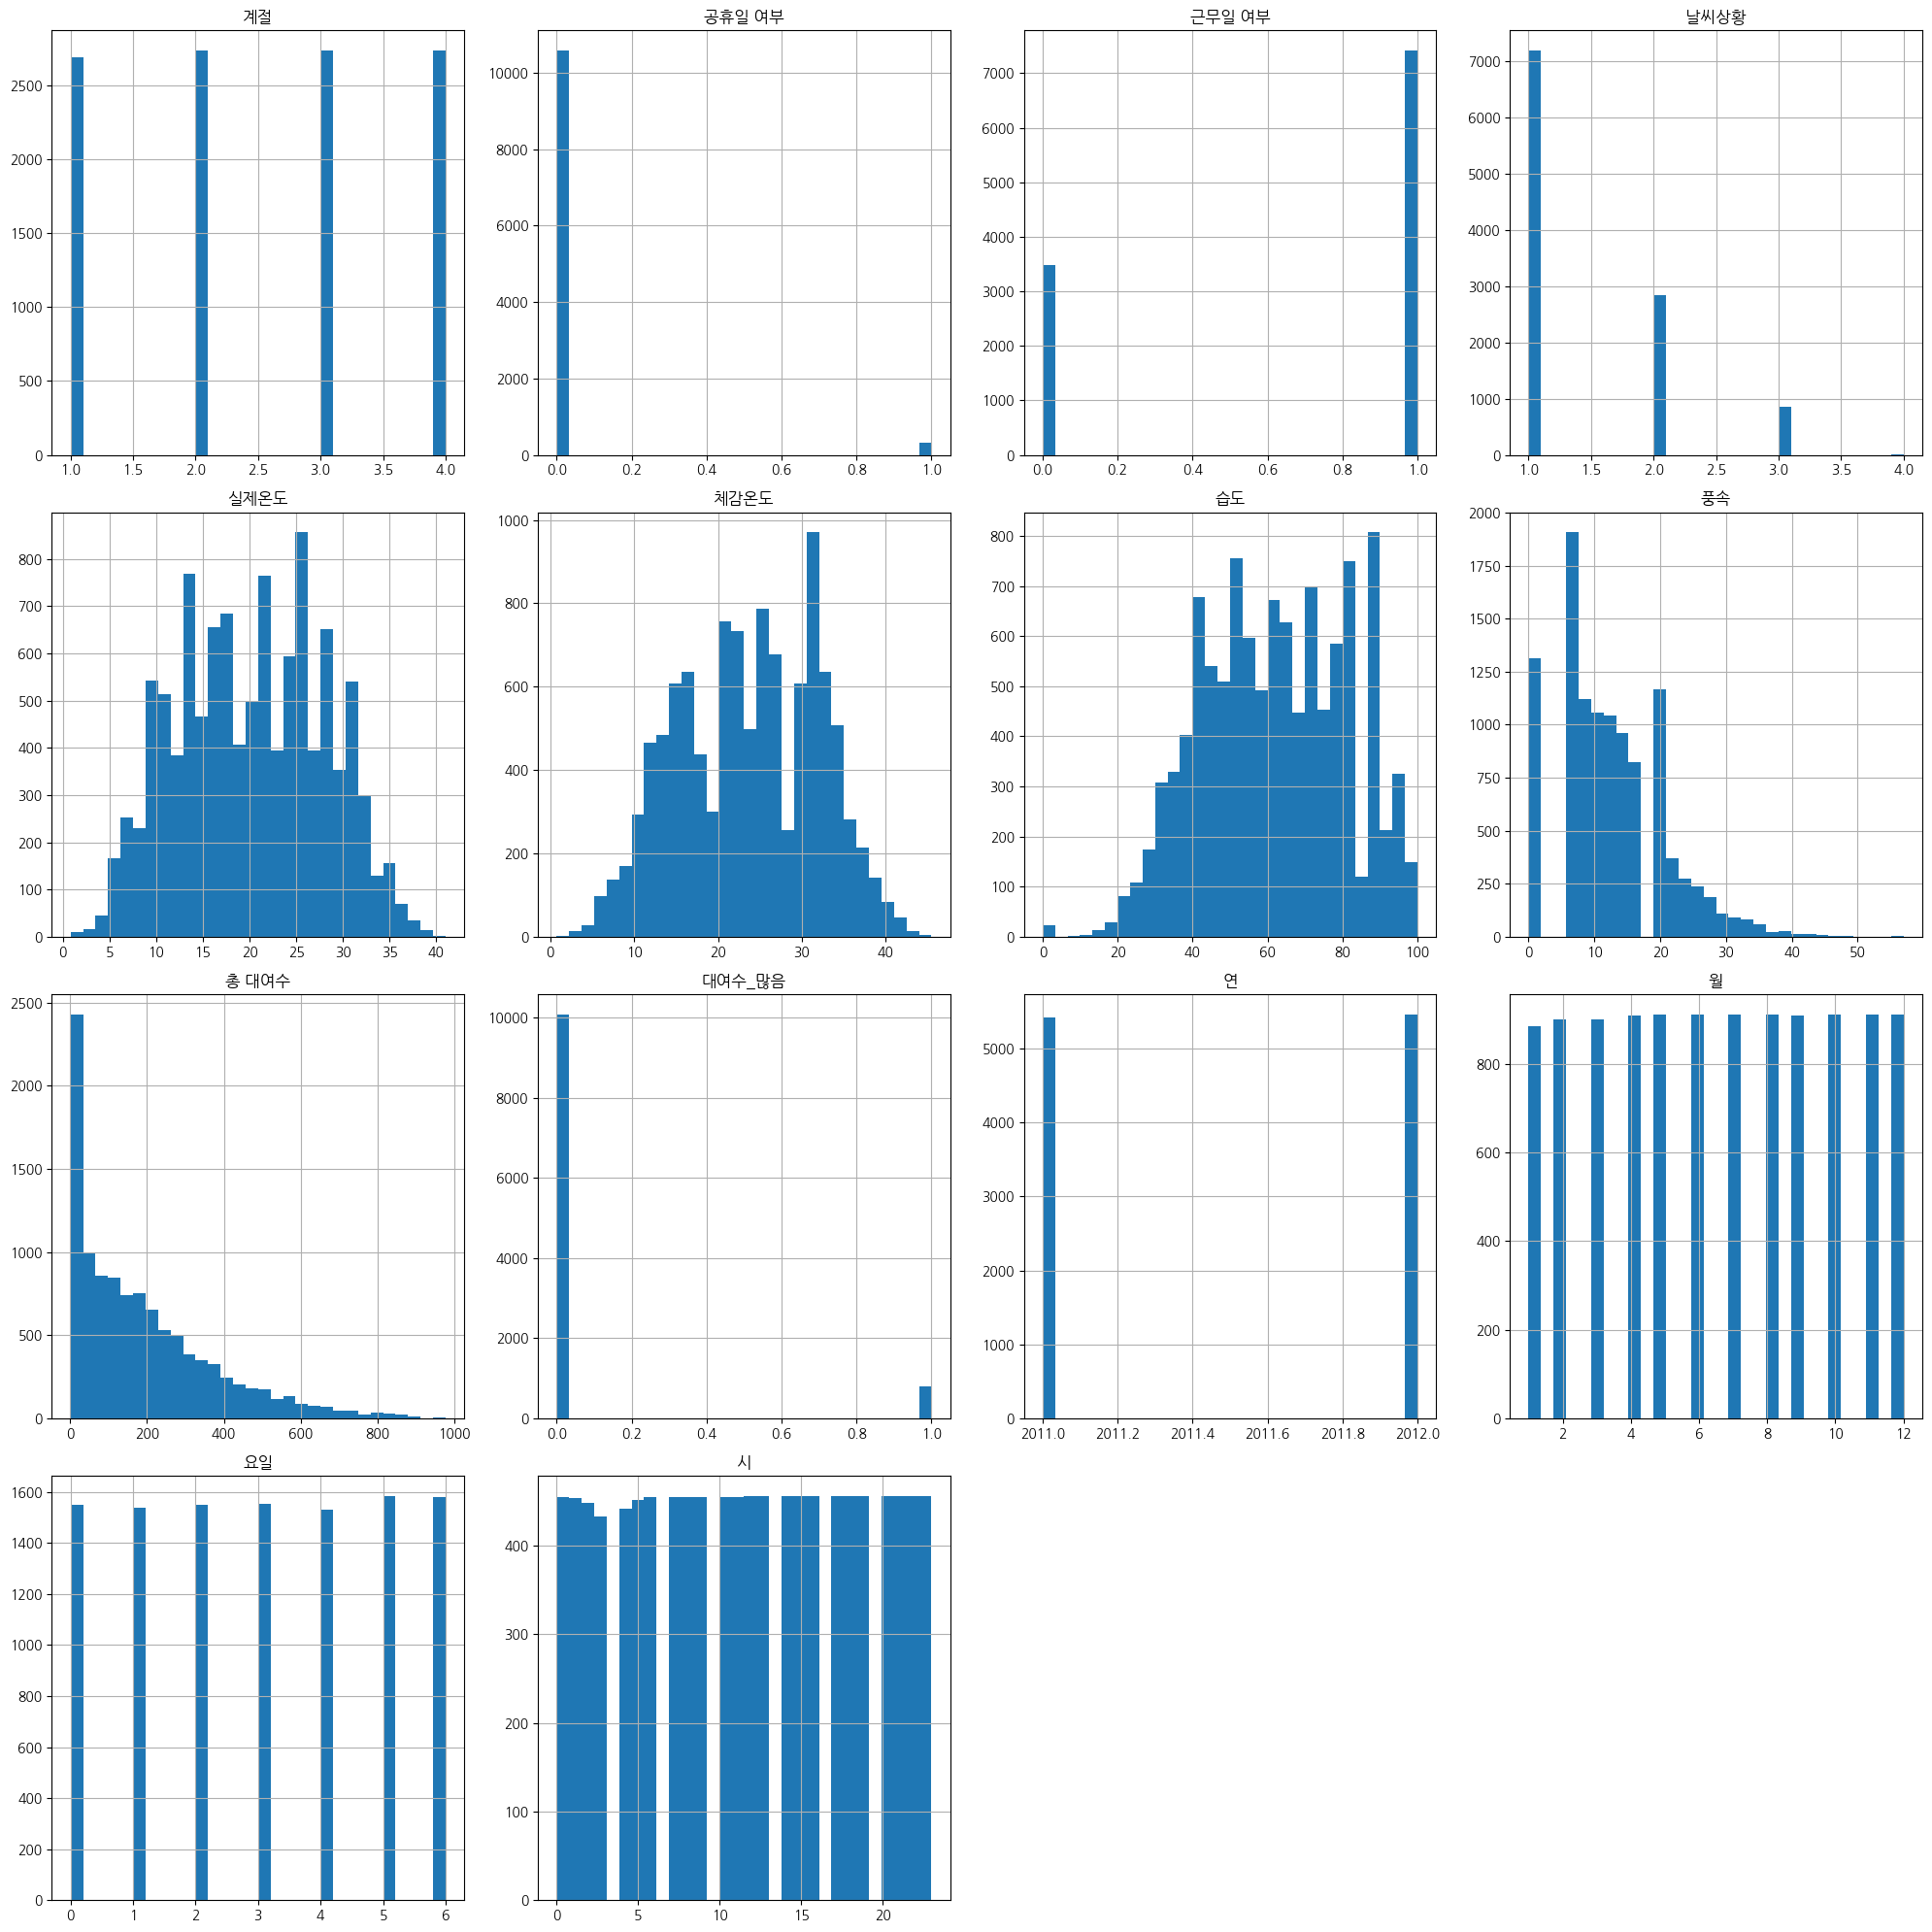

In [ ]:
import matplotlib.pyplot as plt

df.hist(bins = 30, figsize = (20,20))
plt.tight_layout()
plt.show()

> 분포를 통해 데이터의 타입(연속형, 비연속형), 이상치, 밀집도 등을 파악

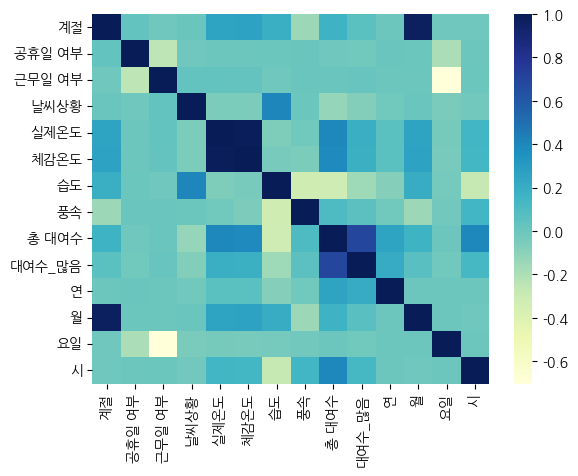

In [ ]:
import seaborn as sns

seq = df.select_dtypes(include='number')
corr = seq.corr(method='pearson')
sns.heatmap(corr, cmap = 'YlGnBu')
plt.show()

> 상관관계가 너무 높은 변수는 다중공선성 문제를 일으키므로 제거하는것이 좋음

In [ ]:
leak_cols = ['등록된 사용자 대여수', '등록되지 않은 사용자 대여수']
df.drop(columns=[c for c in leak_cols if c in df.columns], inplace=True)

#문제에 맞는 결과 데이터

- 회귀 : 연속형 숫자

- 분류 : 비연속형 정수

In [ ]:
#수치형 분리
seq = df.select_dtypes('number').drop('총 대여수',axis = 1)
#범주형 분리
cate = df.select_dtypes('object')

seq_X = seq.columns
cate_X = cate.columns

df['대여수_많음'] = (df['총 대여수'] >500).astype(int)
y = df['대여수_많음']


In [ ]:
print("라벨 분포:\n", y.value_counts())

라벨 분포:
 대여수_많음
0    10089
1      797
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['총 대여수', '대여수_많음'])

#결측치 처리

In [ ]:
df.isna().any(axis=0)

,0
계절,False
공휴일 여부,False
근무일 여부,False
날씨상황,False
실제온도,False
체감온도,False
습도,False
풍속,False
총 대여수,False
대여수_많음,False


#이상치 처리

In [ ]:
#평균과 표준편차
mean = df[seq_X].mean()
std_dev = df[seq_X].std()

#이상치 기준
lower_bound = mean - 3 * std_dev
upper_bound = mean + 3 * std_dev

outlier = ((df[seq_X] < lower_bound) | (df[seq_X] > upper_bound)).any(axis = 1)
~outlier

,0
0,True
1,True
2,True
3,True
4,True
...,...
10881,True
10882,True
10883,True
10884,True


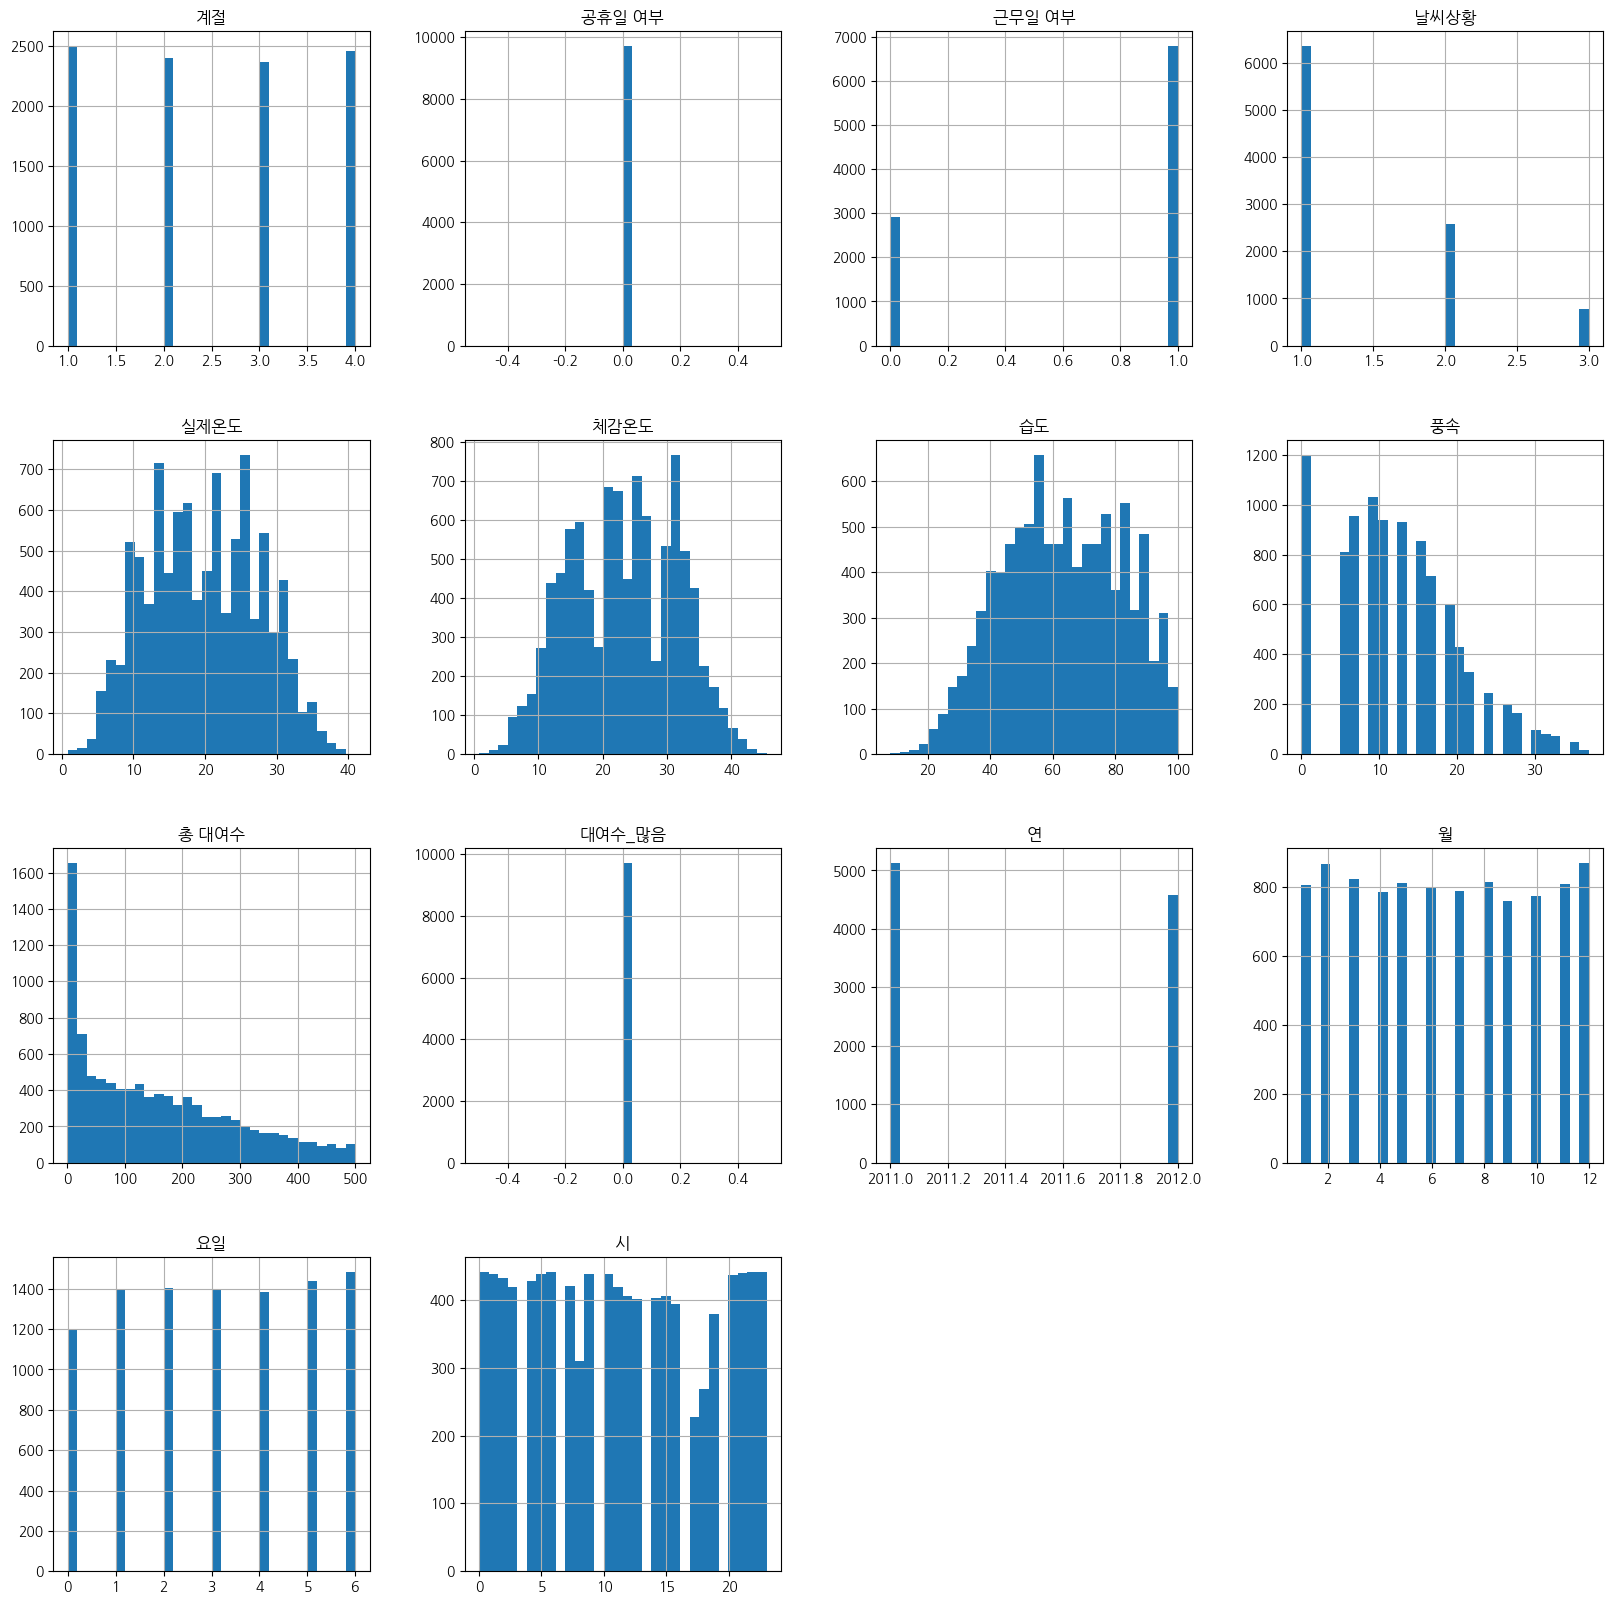

In [ ]:
#히스토그램을 활용한 결과 파악
import matplotlib.pyplot as plt

df[~outlier].hist(bins = 30, figsize = (20,20))
plt.tight_layout
plt.show()

#데이터세트 구성

데이터세트 형상

- Feature 형상 : (샘플개수, 변수개수)
- label 형상 : (샘플개수)

In [ ]:
import numpy as np
import pandas as pd

df['대여수_많음'] = (df['총 대여수'] > 500).astype(int)
y = df['대여수_많음'].astype(int)
X = df.drop(columns=['총 대여수', '대여수_많음'])

print(f'입력데이터 형상: {X.shape}')
print(f'결과데이터 형상: {y.shape}')

입력데이터 형상: (10886, 12)
결과데이터 형상: (10886,)


#train/test 분리

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#전처리 + 모델 파이프라인

In [ ]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ],
    remainder='drop'
)
pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(class_weight='balanced', max_iter=2000))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['계절', '공휴일 여부', '근무일 여부', '날씨상황', '실제온도', '체감온도', '습도', '풍속', '연', '월',
       '요일', '시'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

#확률 예측

In [ ]:
proba = pipe.predict_proba(X_test)[:, 1]

print("\n[Threshold Sweep]")
for t in np.arange(0.2, 0.6, 0.05):
    pred_t = (proba >= t).astype(int)
    p = precision_score(y_test, pred_t, zero_division=0)
    r = recall_score(y_test, pred_t, zero_division=0)
    print(f"Threshold {t:.2f} → Precision {p:.3f}, Recall {r:.3f}")


[Threshold Sweep]
Threshold 0.20 → Precision 0.129, Recall 1.000
Threshold 0.25 → Precision 0.139, Recall 0.975
Threshold 0.30 → Precision 0.152, Recall 0.956
Threshold 0.35 → Precision 0.167, Recall 0.931
Threshold 0.40 → Precision 0.182, Recall 0.912
Threshold 0.45 → Precision 0.195, Recall 0.874
Threshold 0.50 → Precision 0.208, Recall 0.849
Threshold 0.55 → Precision 0.223, Recall 0.824


학습데이터 vs 테스트 데이터 비교

In [ ]:
train_pred = pipe.predict(X_train)
test_pred = pipe.predict(X_test)

from sklearn.metrics import accuracy_score

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.7428801102434544
Test Accuracy : 0.7525252525252525


#최종 결과

In [ ]:
final_threshold = 0.40  # ← 선택한 값

proba = pipe.predict_proba(X_test)[:, 1]
final_pred = (proba >= final_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Final Threshold:", final_threshold)
print("\nConfusion Matrix")
print(confusion_matrix(y_test, final_pred))

print("\nClassification Report")
print(classification_report(y_test, final_pred))

Final Threshold: 0.4

Confusion Matrix
[[1368  651]
 [  14  145]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.68      0.80      2019
           1       0.18      0.91      0.30       159

    accuracy                           0.69      2178
   macro avg       0.59      0.79      0.55      2178
weighted avg       0.93      0.69      0.77      2178

